In [1]:
import os
import copy
import torch
import torch.nn as nn
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
from tqdm import tqdm
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

In [2]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(DEVICE)

NUM_CLASSES = 16
BATCH_SIZE = 16

TRAIN_DIR = "train"
VAL_DIR = "unused_validation"
CORRUPT_VAL_DIR = "new_validation"
TEST_DIR = "test"

cuda


In [3]:
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [4]:
def get_model():
    model = models.resnet50(pretrained=True)
    model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
    return model.to(DEVICE)

In [5]:
def get_client_loader(client_name):
    client_path = os.path.join(TRAIN_DIR, client_name)
    print(f"Loading data from {client_path}")
    dataset = datasets.ImageFolder(client_path, transform=train_transform)
    print(f"Number of training data instances: {len(dataset)}")
    return DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

In [6]:
clean_val_loader = DataLoader(
    datasets.ImageFolder(VAL_DIR, transform=eval_transform),
    batch_size=BATCH_SIZE,
    shuffle=False
)

corrupt_val_loader = DataLoader(
    datasets.ImageFolder(CORRUPT_VAL_DIR, transform=eval_transform),
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [7]:
clients = sorted([
    d for d in os.listdir(TRAIN_DIR)
    if os.path.isdir(os.path.join(TRAIN_DIR, d)) and not d.startswith(".")
])

print(f"Found clients: {clients}")

Found clients: ['client_1', 'client_2', 'client_3', 'client_4', 'client_5']


In [8]:
CKPT_DIR = "ResNet-50"

client_models = []
client_val_accs = []
client_val_f1s = []

for client in clients:
    ckpt_path = os.path.join(CKPT_DIR, f"{client}.pth")

    checkpoint = torch.load(ckpt_path)

    model = get_model()
    model.load_state_dict(checkpoint["model_state_dict"])

    client_models.append(model)
    client_val_accs.append(checkpoint["val_accuracy"])
    client_val_f1s.append(checkpoint["val_f1"])
    print(f"Done: {client}")

/home/btlab/Desktop/Shopon/heterogeneous_split_data/myenv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/btlab/Desktop/Shopon/heterogeneous_split_data/myenv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Done: client_1
Done: client_2
Done: client_3
Done: client_4
Done: client_5


In [9]:
for i in range(len(client_val_accs)):
    print(f"Client {i+1}: Acc={client_val_accs[i]:.4f}, F1={client_val_f1s[i]:.4f}")

Client 1: Acc=0.8535, F1=0.8535
Client 2: Acc=0.8277, F1=0.8303
Client 3: Acc=0.8393, F1=0.8381
Client 4: Acc=0.8351, F1=0.8360
Client 5: Acc=0.8371, F1=0.8381


In [10]:
def evaluate(model, loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            outputs = model(x)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='macro')  
    recall = recall_score(all_labels, all_preds, average='macro')
    f1 = f1_score(all_labels, all_preds, average='macro')

    return acc, precision, recall, f1

def average_models(models):
    avg_model = copy.deepcopy(models[0])
    avg_dict = avg_model.state_dict()

    for key in avg_dict.keys():
        tensors = [m.state_dict()[key] for m in models]

        if tensors[0].dtype in [torch.float32, torch.float64, torch.float16]:
            avg_dict[key] = torch.stack(tensors, dim=0).mean(dim=0)
        else:
            avg_dict[key] = tensors[0]

    avg_model.load_state_dict(avg_dict)
    return avg_model

def greedy_soup(models, val_loader, val_scores):
    sorted_indices = sorted(range(len(models)), key=lambda i: val_scores[i], reverse=True)
    soup_model = copy.deepcopy(models[sorted_indices[0]])
    best_score = val_scores[sorted_indices[0]]
    selected = [sorted_indices[0]]

    for idx in sorted_indices[1:]:
        temp_model = average_models([soup_model, models[idx]])
        score = evaluate(temp_model, val_loader)[0]

        if score > best_score:
            soup_model = temp_model
            best_score = score
            selected.append(idx)

    return soup_model, selected, val_scores

def reliability_weighted_avg(models, reliabilities, selected_indices):
    weights = torch.tensor([reliabilities[i] for i in selected_indices])
    weights = weights / weights.sum()

    global_model = copy.deepcopy(models[selected_indices[0]])
    global_dict = global_model.state_dict()

    for key in global_dict.keys():
        weighted_params = torch.stack([
            weights[i] * models[selected_indices[i]].state_dict()[key]
            for i in range(len(selected_indices))
        ], dim=0)
        
        global_dict[key] = weighted_params.sum(dim=0)

    global_model.load_state_dict(global_dict)
    return global_model

In [11]:
selected_indices = [0,4]

resofed_model = reliability_weighted_avg(
    client_models,
    client_val_accs,
    selected_indices
)

In [12]:
import numpy as np

corrupt_client_val_accs = [0.7931, 0.8033, 0.8069, 0.7764, 0.8101] 

A_clean = np.array(client_val_accs)
A_corrupt = np.array(corrupt_client_val_accs)

robustness = A_corrupt * (A_corrupt / (A_clean + 1e-8))  # Adding small epsilon to avoid division by zero
alpha = 0.5 
reliability = alpha * A_clean + (1 - alpha) * robustness

print("Reliability Scores:", reliability)

resofed_doc_model = reliability_weighted_avg(
    client_models,
    reliability,
    selected_indices
)

Reliability Scores: [0.79523667 0.80365939 0.80752507 0.77846587 0.81053676]


In [13]:
def fedavg(models):

    global_model = copy.deepcopy(models[0])
    global_dict = global_model.state_dict()

    for key in global_dict.keys():

        tensors = [models[i].state_dict()[key] for i in range(len(models))]

        if tensors[0].dtype.is_floating_point:
            global_dict[key] = torch.stack(tensors, dim=0).mean(dim=0)
        else:
            global_dict[key] = tensors[0]

    global_model.load_state_dict(global_dict)
    return global_model

fedavg_model = fedavg(client_models)

In [14]:
def get_target_layer(model):
    # ConvNeXt / ResNet
    if hasattr(model, "layer4"):
        return model.layer4[-1]
    
    # Swin / ViT (approximate choice)
    elif hasattr(model, "features"):
        return model.features[-1]
    
    else:
        raise ValueError("Define target layer for your model")

In [15]:
# def generate_gradcam(cam, model, input_tensor):
#     model.eval()
    
#     # input_tensor = input_tensor.unsqueeze(0).to(next(model.parameters()).device)
#     input_tensor = input_tensor.to(next(model.parameters()).device)

#     # forward to get predicted class
#     with torch.no_grad():
#         outputs = model(input_tensor)
#         pred_class = outputs.argmax(dim=1).item()

#     targets = [ClassifierOutputTarget(pred_class)]

#     grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
#     heatmap = grayscale_cam[0]

#     # normalize
#     heatmap = heatmap / (heatmap.max() + 1e-8)

#     return heatmap

def generate_gradcam(cam, model, input_tensor):
    model.eval()

    input_tensor = input_tensor.to(next(model.parameters()).device)

    outputs = model(input_tensor)
    pred_class = outputs.argmax(dim=1).item()  # ✅ now valid

    targets = [ClassifierOutputTarget(pred_class)]

    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
    heatmap = grayscale_cam[0]

    heatmap = heatmap / (heatmap.max() + 1e-8)

    return heatmap

In [16]:
def compute_similarity(h1, h2):
    return cosine_similarity(
        h1.flatten().reshape(1, -1),
        h2.flatten().reshape(1, -1)
    )[0][0]

In [17]:
def evaluate_stability(model, clean_loader, corrupt_loader):
    device = next(model.parameters()).device
    model.eval()

    target_layer = get_target_layer(model)
    cam = GradCAM(model=model, target_layers=[target_layer])

    similarities = []

    # for (clean_img, _), (corrupt_img, _) in tqdm(zip(clean_loader, corrupt_loader)):
        
    #     clean_img = clean_img.to(device)
    #     corrupt_img = corrupt_img.to(device)

    #     heatmap_clean = generate_gradcam(cam, model, clean_img)
    #     heatmap_corrupt = generate_gradcam(cam, model, corrupt_img)

    #     sim = compute_similarity(heatmap_clean, heatmap_corrupt)
    #     similarities.append(sim)

    for (clean_imgs, _), (corrupt_imgs, _) in tqdm(zip(clean_loader, corrupt_loader)):
        clean_imgs = clean_imgs.to(device)
        corrupt_imgs = corrupt_imgs.to(device)
        batch_size = clean_imgs.size(0)
        for i in range(batch_size):
            clean_img = clean_imgs[i].unsqueeze(0)     # [1, 3, H, W]
            corrupt_img = corrupt_imgs[i].unsqueeze(0)
            heatmap_clean = generate_gradcam(cam, model, clean_img)
            heatmap_corrupt = generate_gradcam(cam, model, corrupt_img)
            sim = compute_similarity(heatmap_clean, heatmap_corrupt)
            similarities.append(sim)


    return np.mean(similarities)

In [ ]:
models = {
    "FedAvg": fedavg_model,
    "ReSoFed": resofed_model,
    "ReSoFed-Doc": resofed_doc_model
}

results = {}

for name, model in models.items():
    print(f"Evaluating {name}...")
    score = evaluate_stability(model, clean_val_loader, corrupt_val_loader)
    results[name] = score

print("\nStability Results:")
for k, v in results.items():
    print(f"{k}: {v:.4f}")

In [18]:
def compute_iou(heatmap_clean, heatmap_corrupt, threshold=0.5):
    # normalize (safety)
    heatmap_clean = heatmap_clean / (heatmap_clean.max() + 1e-8)
    heatmap_corrupt = heatmap_corrupt / (heatmap_corrupt.max() + 1e-8)

    # threshold → binary masks
    mask_clean = heatmap_clean > threshold
    mask_corrupt = heatmap_corrupt > threshold

    # intersection & union
    intersection = np.logical_and(mask_clean, mask_corrupt).sum()
    union = np.logical_or(mask_clean, mask_corrupt).sum()

    return intersection / (union + 1e-8)

In [19]:
def evaluate_stability_iou(model, clean_loader, corrupt_loader, threshold=0.5):
    device = next(model.parameters()).device
    model.eval()

    target_layer = get_target_layer(model)
    cam = GradCAM(model=model, target_layers=[target_layer])

    iou_scores = []

    for (clean_imgs, _), (corrupt_imgs, _) in tqdm(zip(clean_loader, corrupt_loader)):

        clean_imgs = clean_imgs.to(device)
        corrupt_imgs = corrupt_imgs.to(device)

        batch_size = clean_imgs.size(0)

        for i in range(batch_size):
            clean_img = clean_imgs[i].unsqueeze(0)     # [1, 3, H, W]
            corrupt_img = corrupt_imgs[i].unsqueeze(0)

            heatmap_clean = generate_gradcam(cam, model, clean_img)
            heatmap_corrupt = generate_gradcam(cam, model, corrupt_img)

            iou = compute_iou(heatmap_clean, heatmap_corrupt, threshold)
            iou_scores.append(iou)

    return np.mean(iou_scores)



In [ ]:
models = {
    "FedAvg": fedavg_model,
    "ReSoFed": resofed_model,
    "ReSoFed-Doc": resofed_doc_model
}
iou_results = {}

for name, model in models.items():
    print(f"Evaluating IoU stability for {name}...")
    score = evaluate_stability_iou(model, clean_val_loader, corrupt_val_loader)
    iou_results[name] = score

print("\nIoU Stability Results:")
for k, v in iou_results.items():
    print(f"{k}: {v:.4f}")

In [21]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget


def get_target_layer(model):

    # ResNet
    if hasattr(model, "layer4"):
        return model.layer4[-1]

    # ConvNeXt
    elif hasattr(model, "features"):
        return model.features[-1]

    # Swin / ViT (modify if needed)
    elif hasattr(model, "layers"):
        return model.layers[-1]

    else:
        raise ValueError("Please define target layer manually.")

In [67]:
import matplotlib.pyplot as plt

# Reverse normalization for visualization
def denormalize(img_tensor, mean, std):

    img = img_tensor.clone().cpu()

    for t, m, s in zip(img, mean, std):
        t.mul_(s).add_(m)

    img = img.permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    return img

# Generate GradCAM overlay
def generate_gradcam_overlay(model, input_tensor):

    device = next(model.parameters()).device
    model.eval()

    target_layer = get_target_layer(model)

    cam = GradCAM(
        model=model,
        target_layers=[target_layer]
    )

    input_tensor = input_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        pred_class = output.argmax(dim=1).item()

    targets = [ClassifierOutputTarget(pred_class)]

    grayscale_cam = cam(
        input_tensor=input_tensor,
        targets=targets
    )[0]

    grayscale_cam = grayscale_cam / (grayscale_cam.max() + 1e-8)

    # Convert image back to RGB
    rgb_img = denormalize(
        input_tensor[0],
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )

    visualization = show_cam_on_image(
        rgb_img,
        grayscale_cam,
        use_rgb=True
    )

    return rgb_img, visualization


# Visualize clean vs corrupted for all methods
def visualize_gradcam_comparison(
    clean_img,
    corrupt_img,
    FedAvg_model,
    ReSoFed_model,
    ReSoFed_Doc_model,
    number
):

    methods = {
        "FedAvg": FedAvg_model,
        "ReSoFed": ReSoFed_model,
        "ReSoFed-Doc": ReSoFed_Doc_model
    }

    fig, axes = plt.subplots(
        nrows=3,
        ncols=2,
        figsize=(8, 12)
    )

    for row_idx, (name, model) in enumerate(methods.items()):

        clean_rgb, clean_vis = generate_gradcam_overlay(
            model,
            clean_img
        )

        corrupt_rgb, corrupt_vis = generate_gradcam_overlay(
            model,
            corrupt_img
        )

        axes[row_idx, 0].imshow(clean_vis)
        axes[row_idx, 0].set_title(f"{name} - Clean")
        axes[row_idx, 0].axis("off")

        axes[row_idx, 1].imshow(corrupt_vis)
        axes[row_idx, 1].set_title(f"{name} - Corrupt")
        axes[row_idx, 1].axis("off")

    plt.tight_layout()
    plt.savefig(f"gradcam_comparison_{number}.png")
    plt.show()

In [85]:
clean_paths = clean_val_loader.dataset.samples
corrupt_paths = corrupt_val_loader.dataset.samples

corrupt_map = {}

for path, label in corrupt_paths:

    filename = os.path.basename(path)

    # Extract original ID
    original_name = filename.split("_")[-1]

    corrupt_map[original_name] = path

In [144]:
idx = 16579

clean_path, label = clean_paths[idx]

clean_filename = os.path.basename(clean_path)

corrupt_path = corrupt_map[clean_filename]

print(clean_path)
print(corrupt_path)

unused_validation/7/2031552040.tif
new_validation/7/group1_blur_lowres_compression_2031552040.tif


In [145]:
from PIL import Image

clean_img_pil = Image.open(clean_path).convert("RGB")
corrupt_img_pil = Image.open(corrupt_path).convert("RGB")

clean_img = eval_transform(clean_img_pil)
corrupt_img = eval_transform(corrupt_img_pil)

In [ ]:
# import torch
# import torch.nn as nn

# original_resofed_model = copy.deepcopy(resofed_model)

# with torch.no_grad():
#     for param in original_resofed_model.parameters():
#         param.add_(0)

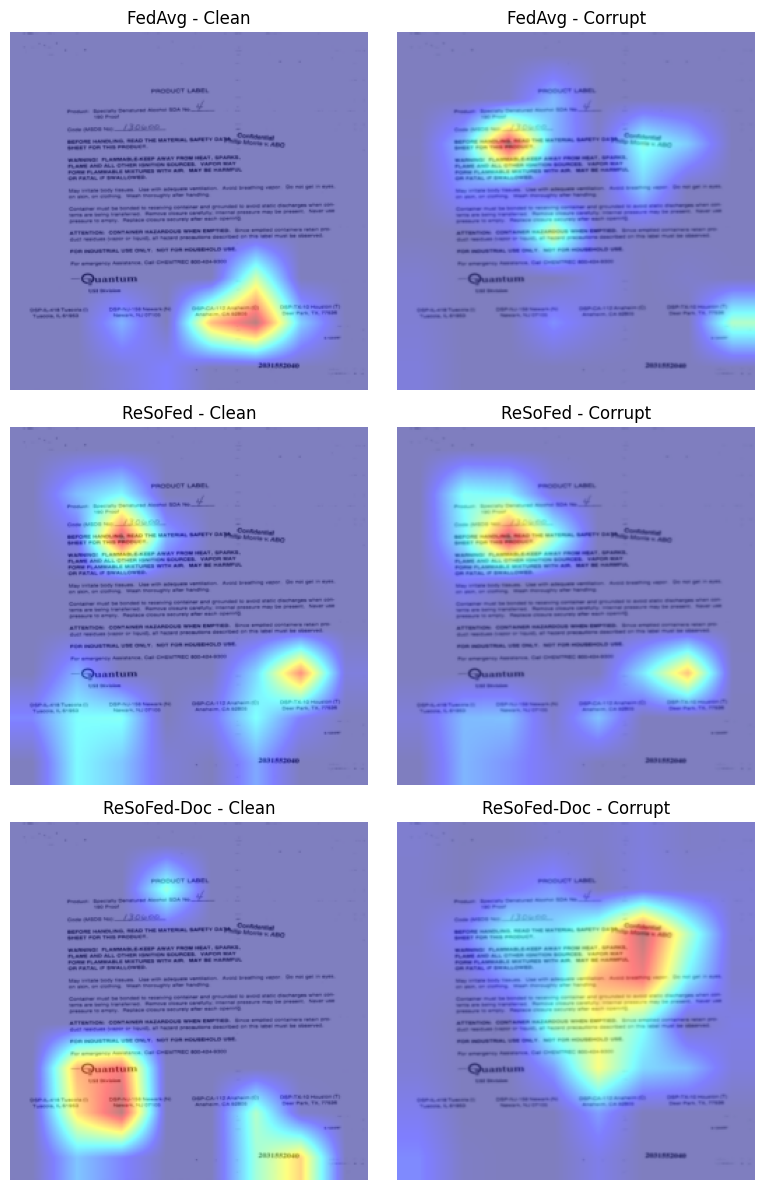

In [ ]:
visualize_gradcam_comparison(
    clean_img,
    corrupt_img,
    fedavg_model,
    resofed_model,
    resofed_doc_model,
    number=7
)